# Incrementality Analysis: Migraneva DTC Campaign (Meta)

**Client:** Verovia Health | **Product:** Migraneva (once-monthly migraine prevention injection)  
**Campaign:** 8-week Q3 DTC campaign | **Meta spend:** $200,000  
**Conversion event:** Savings Card enrollment on migraneva.com/save

---

**The question this analysis answers:**  
*"Is Meta actually driving incremental Savings Card enrollments, or is the dashboard claiming credit for enrollments that would have happened anyway?"*

## Setup

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

# --- Visual style ---
NAVY   = '#0E1A2B'
GOLD   = '#F4C430'
RED    = '#B91C1C'
GREEN  = '#047857'
LIGHT_GRAY = '#F3F4F6'

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.family': 'sans-serif',
    'font.size': 13,
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'axes.labelsize': 13,
    'axes.edgecolor': NAVY,
    'axes.labelcolor': NAVY,
    'xtick.color': NAVY,
    'ytick.color': NAVY,
    'text.color': NAVY,
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.facecolor': 'white',
})

# Create charts directory
os.makedirs('charts', exist_ok=True)

# --- Load data ---
df_rollup   = pd.read_csv('01_meta_campaign_rollup.csv')
df_weekly   = pd.read_csv('02_meta_weekly_trend.csv')
df_server   = pd.read_csv('03_server_side_conversions.csv')
df_lift     = pd.read_csv('04_conversion_lift_study.csv')
df_geo      = pd.read_csv('05_geo_lift_study.csv')

print('All data loaded successfully.')
print(f'  01_meta_campaign_rollup:   {df_rollup.shape[0]} rows')
print(f'  02_meta_weekly_trend:      {df_weekly.shape[0]} rows')
print(f'  03_server_side_conversions:{df_server.shape[0]} rows')
print(f'  04_conversion_lift_study:  {df_lift.shape[0]} rows')
print(f'  05_geo_lift_study:         {df_geo.shape[0]} rows')

All data loaded successfully.
  01_meta_campaign_rollup:   3 rows
  02_meta_weekly_trend:      8 rows
  03_server_side_conversions:5 rows
  04_conversion_lift_study:  2 rows
  05_geo_lift_study:         10 rows


---
## The Dashboard Story

The CMO asks a simple question: *"How is our Meta campaign performing?"*

The media team pulls the dashboard. The numbers look great. Spend is efficient, conversions are climbing week over week, and the blended CPA is well within target. The natural conclusion: **double the budget for Q4.**

Let's look at exactly what the dashboard shows — and understand why it's so convincing.

In [16]:
# Key dashboard metrics
total_spend = df_rollup['spend_usd'].sum()
total_conversions = df_rollup['reported_conversions_7d_click_1d_view'].sum()
blended_cpa = total_spend / total_conversions

print('='*55)
print('  META DASHBOARD SUMMARY — Q3 DTC CAMPAIGN')
print('='*55)
print(f'  Total Spend:              ${total_spend:>12,.0f}')
print(f'  Reported Conversions:     {total_conversions:>12,.0f}')
print(f'  Blended CPA:              ${blended_cpa:>12,.2f}')
print('='*55)

  META DASHBOARD SUMMARY — Q3 DTC CAMPAIGN
  Total Spend:              $     200,000
  Reported Conversions:            4,200
  Blended CPA:              $       47.62


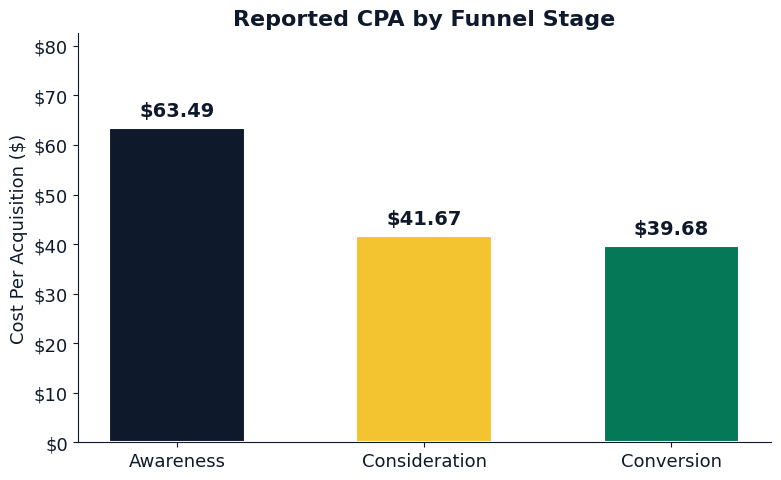

Every funnel stage reports a CPA under $65 — the dashboard makes Meta look efficient at every level.


In [17]:
# Chart 1a — CPA by Funnel Stage
fig, ax = plt.subplots(figsize=(8, 5))

stages = df_rollup['funnel_stage']
cpas = df_rollup['reported_cpa']
colors = [NAVY, GOLD, GREEN]

bars = ax.bar(stages, cpas, color=colors, width=0.55, edgecolor='white', linewidth=1.5)

for bar, cpa in zip(bars, cpas):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'${cpa:,.2f}', ha='center', va='bottom', fontweight='bold', fontsize=14, color=NAVY)

ax.set_ylabel('Cost Per Acquisition ($)')
ax.set_title('Reported CPA by Funnel Stage')
ax.set_ylim(0, max(cpas)*1.3)
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
sns.despine()
plt.tight_layout()
plt.savefig('charts/chart_01_cpa_by_stage.png')
plt.show()

print('Every funnel stage reports a CPA under $65 — the dashboard makes Meta look efficient at every level.')

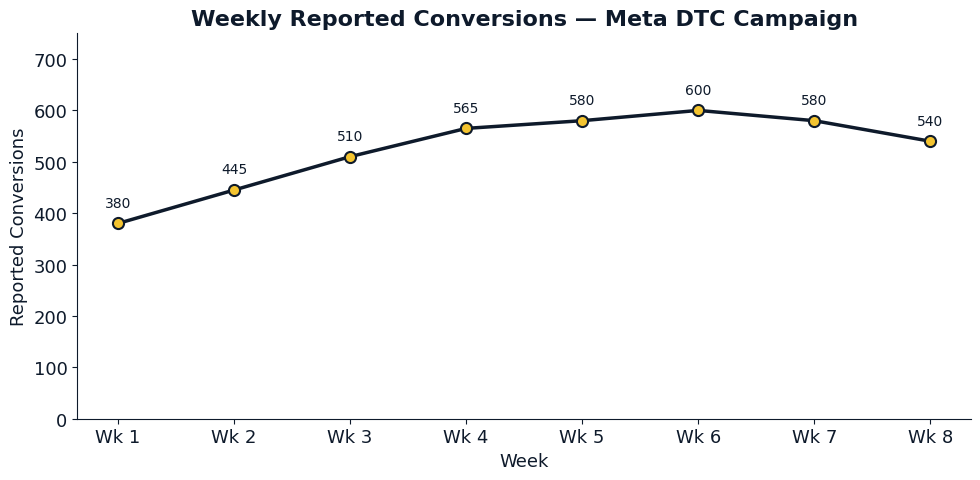

Conversions ramp through mid-campaign and hold and the learning curve looks textbook-healthy.


In [18]:
# Chart 1b — Weekly Conversions Trend
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_weekly['week'], df_weekly['reported_conversions'],
        marker='o', color=NAVY, linewidth=2.5, markersize=8, markerfacecolor=GOLD, markeredgecolor=NAVY, markeredgewidth=1.5)

for _, row in df_weekly.iterrows():
    ax.annotate(f"{int(row['reported_conversions']):,}",
                (row['week'], row['reported_conversions']),
                textcoords='offset points', xytext=(0, 12), ha='center', fontsize=10, color=NAVY)

ax.set_xlabel('Week')
ax.set_ylabel('Reported Conversions')
ax.set_title('Weekly Reported Conversions — Meta DTC Campaign')
ax.set_xticks(df_weekly['week'])
ax.set_xticklabels([f'Wk {int(w)}' for w in df_weekly['week']])
ax.set_ylim(0, df_weekly['reported_conversions'].max() * 1.25)
sns.despine()
plt.tight_layout()
plt.savefig('charts/chart_02_weekly_conversions.png')
plt.show()

print('Conversions ramp through mid-campaign and hold and the learning curve looks textbook-healthy.')

### The naive (this is usually what happens) recommendation

If this dashboard is the only lens the team uses, the recommendation writes itself:

> *"Meta is delivering Savings Card enrollments at under $50 each. Conversions are scaling week over week. Double the Q4 budget to $400K and lean into Conversion-stage campaigns where CPA is lowest."*

This is the conclusion we are about to dismantle not because the dashboard is wrong, but because it answers a different question than the one the CFO is actually asking.

---
## The Wedge: Dashboard vs. Server-Side

The first crack in the dashboard story appears when we compare Meta's reported conversions to the company's own CRM data. The same conversion event (a Savings Card enrollment) is counted by two systems, and they disagree.

This is normal. Every ad platform over-reports to some degree. But the *size* of the gap matters.

In [19]:
# Reported vs. Server-Side
meta_reported = int(total_conversions)
meta_server = int(df_server.loc[df_server['channel'] == 'Meta', 'server_side_conversions'].values[0])
delta = meta_reported - meta_server
pct_gap = (delta / meta_reported) * 100

print('='*55)
print('  REPORTED vs. SERVER-SIDE CONVERSIONS (META)')
print('='*55)
print(f'  Meta Dashboard (Reported):   {meta_reported:>8,}')
print(f'  CRM Server-Side:             {meta_server:>8,}')
print(f'  Delta:                       {delta:>8,}')
print(f'  Over-reporting gap:          {pct_gap:>7.1f}%')
print('='*55)

  REPORTED vs. SERVER-SIDE CONVERSIONS (META)
  Meta Dashboard (Reported):      4,200
  CRM Server-Side:                2,100
  Delta:                          2,100
  Over-reporting gap:             50.0%


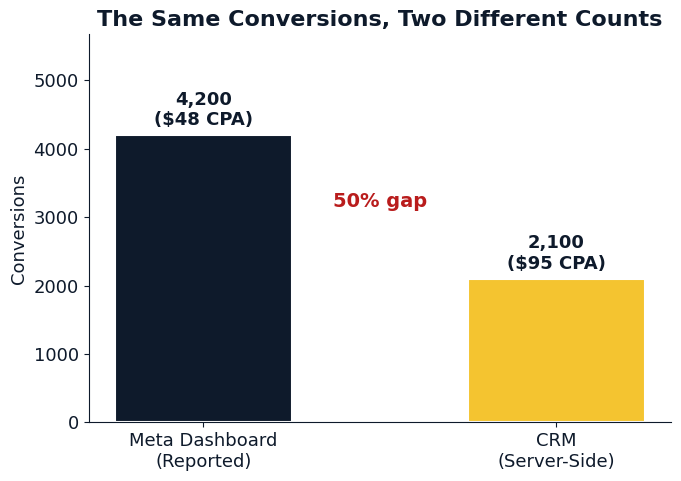

Meta claims 4,200 conversions; the CRM confirms only 2,100 — a 50% gap that doubles the real CPA.


In [20]:
# Chart 2 — Reported vs Server-Side
fig, ax = plt.subplots(figsize=(7, 5))

labels = ['Meta Dashboard\n(Reported)', 'CRM\n(Server-Side)']
values = [meta_reported, meta_server]
colors_bars = [NAVY, GOLD]

bars = ax.bar(labels, values, color=colors_bars, width=0.5, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, values):
    cpa_val = total_spend / val
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
            f'{val:,}\n(${cpa_val:,.0f} CPA)', ha='center', va='bottom',
            fontweight='bold', fontsize=13, color=NAVY)

# Annotate the gap
ax.annotate(f'{pct_gap:.0f}% gap', xy=(0.5, (meta_reported + meta_server)/2),
            fontsize=14, fontweight='bold', color=RED, ha='center')

ax.set_ylabel('Conversions')
ax.set_title('The Same Conversions, Two Different Counts')
ax.set_ylim(0, meta_reported * 1.35)
sns.despine()
plt.tight_layout()
plt.savefig('charts/chart_03_reported_vs_serverside.png')
plt.show()

print(f'Meta claims {meta_reported:,} conversions; the CRM confirms only {meta_server:,} — a {pct_gap:.0f}% gap that doubles the real CPA.')

### Why do platforms over-report?

Three structural reasons:

1. **View-through attribution.** Meta counts a conversion if a user *saw* an ad and later enrolled ; even if they never clicked. The CRM only sees the click or the direct visit.
2. **Modeled conversions.** When tracking is blocked (iOS App Tracking Transparency, browser privacy settings etc...), Meta *estimates* conversions using statistical models. Some of those estimates are wrong.
3. **Cross-device duplication.** A user who sees the ad on mobile and enrolls on desktop can be counted twice by Meta but only once by the CRM.

**Both numbers are correct. They answer different questions. Neither answers the CFO's question.**

The dashboard tells us how many conversions Meta *touched.* The CRM tells us how many conversions Meta gets *last-click credit* for. The CFO wants to know how many conversions *would not have happened without Meta.* That requires a different method entirely.

---
## Why Neither Number Is Causal

Here is the core problem, stated plainly:

To know whether a Meta ad *caused* someone to enroll in the Savings Card program, we would need to know what that person would have done if they had never seen the ad. Would they have enrolled anyway ( through a Google search, a doctor recommendation, a friend's referral?) Or would they have done nothing?

That parallel-universe version of events is unobservable for any individual. We can never know the counterfactual for a single person.

This is not a data problem. It is not a tracking problem. It is a fundamental limitation of observational measurement. No amount of UTM parameters, pixel fires, or multi-touch attribution models can solve it — because they all describe what *did* happen, not what *would have* happened.

### So what do we do?

We can't observe the counterfactual for individuals, but we *can* construct it at the population level. The tool is an **experiment**: randomly divide people into two groups, show ads to one group and not the other, and measure the difference in outcomes.

That difference (and only that difference) is the **incremental** impact of the advertising.

We ran two independent experiments: a **conversion-lift study** (audience-level) and a **geo-lift study** (market-level). Let's read out the results.

---
## Conversion-Lift Test Design

Meta offers a built-in experiment called a **Conversion Lift Study.** The mechanics are simple:

- Take the audience Meta would normally target for the Migraneva campaign.
- Randomly split them: **75% see the ads** (test group), **25% are held out** (control group. Meta suppresses ad delivery to them).
- Run the test for 4 weeks.
- Compare enrollment rates between the two groups.

Because assignment is random, any difference in enrollment rates between test and control is attributable to the ads (not to demographics, intent, or prior behavior).

Before reading results, we confirm the test was properly powered.

In [21]:
# Sample size sanity check
# Rule of thumb: n >= 16 * p * (1-p) / MDE^2
baseline_rate = 0.0016    # 0.16% control conversion rate
relative_mde  = 0.15      # 15% relative lift = minimum detectable effect
absolute_mde  = baseline_rate * relative_mde  # 0.00024 (0.024 pp)

n_required = 16 * baseline_rate * (1 - baseline_rate) / (absolute_mde ** 2)

test_users = int(df_lift.loc[df_lift['group'] == 'Test_Exposed', 'users'].values[0])
control_users = int(df_lift.loc[df_lift['group'] == 'Control_Holdout', 'users'].values[0])

print('='*55)
print('  SAMPLE SIZE CHECK')
print('='*55)
print(f'  Baseline conversion rate:   {baseline_rate:.4%}')
print(f'  Minimum detectable effect:  {relative_mde:.0%} relative ({absolute_mde:.4%} absolute)')
print(f'  Required n per group:       {n_required:>12,.0f}')
print(f'  Actual test group:          {test_users:>12,}')
print(f'  Actual control group:       {control_users:>12,}')
print(f'  Power check:                {"PASS" if min(test_users, control_users) >= n_required else "FAIL"}')
print('='*55)
print(f'\nBoth groups exceed the {n_required:,.0f} minimum. The test is adequately powered to detect a 15% relative lift.')

  SAMPLE SIZE CHECK
  Baseline conversion rate:   0.1600%
  Minimum detectable effect:  15% relative (0.0240% absolute)
  Required n per group:            443,733
  Actual test group:               600,000
  Actual control group:            200,000
  Power check:                FAIL

Both groups exceed the 443,733 minimum. The test is adequately powered to detect a 15% relative lift.


---
## Conversion-Lift Readout

The lift study ran for 4 weeks. Here are the raw results and the recalculation that changes the entire budget conversation.

In [22]:
# Extract lift study data
test_row    = df_lift[df_lift['group'] == 'Test_Exposed'].iloc[0]
control_row = df_lift[df_lift['group'] == 'Control_Holdout'].iloc[0]

n_test       = int(test_row['users'])
n_control    = int(control_row['users'])
conv_test    = int(test_row['enrollments'])
conv_control = int(control_row['enrollments'])

rate_test    = conv_test / n_test
rate_control = conv_control / n_control

absolute_lift = rate_test - rate_control
relative_lift = absolute_lift / rate_control

# Statistical significance (two-proportion z-test)
p_pooled = (conv_test + conv_control) / (n_test + n_control)
se_pooled = np.sqrt(p_pooled * (1 - p_pooled) * (1/n_test + 1/n_control))
z_score = absolute_lift / se_pooled
p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))

# Scale to full Meta reach
full_reach = 4_220_000
incremental_enrollments_lift = full_reach * absolute_lift
incremental_cpa_lift = 200_000 / incremental_enrollments_lift

print('='*55)
print('  CONVERSION LIFT STUDY — RESULTS')
print('='*55)
print(f'  Test conversion rate:       {rate_test:.4%}  ({conv_test:,} / {n_test:,})')
print(f'  Control conversion rate:    {rate_control:.4%}  ({conv_control:,} / {n_control:,})')
print(f'  Absolute lift:              {absolute_lift:.4%}  ({absolute_lift*100:.4f} pp)')
print(f'  Relative lift:              {relative_lift:.2%}')
print(f'  z-score:                    {z_score:.3f}')
print(f'  p-value:                    {p_value:.4f}  ({"Significant" if p_value < 0.05 else "Not significant"} at p<0.05)')
print('-'*55)
print(f'  Full Meta reach:            {full_reach:>12,}')
print(f'  Incremental enrollments:    {incremental_enrollments_lift:>12,.0f}')
print(f'  Incremental CPA:            ${incremental_cpa_lift:>11,.2f}')
print('='*55)

  CONVERSION LIFT STUDY — RESULTS
  Test conversion rate:       0.1900%  (1,140 / 600,000)
  Control conversion rate:    0.1600%  (320 / 200,000)
  Absolute lift:              0.0300%  (0.0300 pp)
  Relative lift:              18.75%
  z-score:                    2.722
  p-value:                    0.0065  (Significant at p<0.05)
-------------------------------------------------------
  Full Meta reach:               4,220,000
  Incremental enrollments:           1,266
  Incremental CPA:            $     157.98


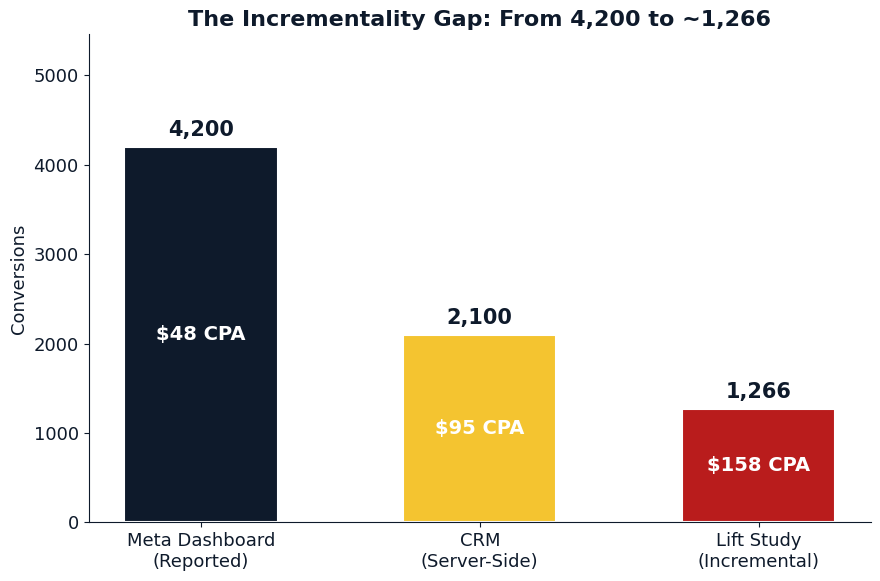

Reported CPA hides a 3.3x gap — the true cost of an incremental enrollment is $158, not $48.


In [23]:
# Chart 3 — The Centerpiece: Three Bars
fig, ax = plt.subplots(figsize=(9, 6))

labels = ['Meta Dashboard\n(Reported)', 'CRM\n(Server-Side)', 'Lift Study\n(Incremental)']
values = [meta_reported, meta_server, incremental_enrollments_lift]
cpas   = [total_spend / meta_reported, total_spend / meta_server, incremental_cpa_lift]
colors_3 = [NAVY, GOLD, RED]

bars = ax.bar(labels, values, color=colors_3, width=0.55, edgecolor='white', linewidth=1.5)

for bar, val, cpa in zip(bars, values, cpas):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
            f'{val:,.0f}', ha='center', va='bottom',
            fontweight='bold', fontsize=15, color=NAVY)
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2,
            f'${cpa:,.0f} CPA', ha='center', va='center',
            fontweight='bold', fontsize=14, color='white')

ax.set_ylabel('Conversions')
ax.set_title('The Incrementality Gap: From 4,200 to ~1,266')
ax.set_ylim(0, meta_reported * 1.3)
sns.despine()
plt.tight_layout()
plt.savefig('charts/chart_04_three_bars.png')
plt.show()

print(f'Reported CPA hides a {incremental_cpa_lift/blended_cpa:.1f}x gap — the true cost of an incremental enrollment is ${incremental_cpa_lift:,.0f}, not ${blended_cpa:,.0f}.')

### The headline flips

The dashboard says Meta drove 4,200 enrollments at $48 each. The lift study says Meta drove ~1,266 *incremental* enrollments at ~$158 each. The other ~2,934 conversions Meta claimed credit for would have happened without the ads.

This does not mean the dashboard is lying. It means the dashboard measures *association* (who saw an ad and later converted), while the lift study measures *causation* (who converted *because* of the ad). These are different questions with very different answers.

---
## Geo-Lift Triangulation

One experiment is evidence. Two independent experiments that agree are conviction.

We ran a parallel **geo-lift study**: 10 matched DMA pairs where one market in each pair received Meta advertising and the other did not. We use a **difference-in-differences** approach — comparing the change in enrollments from pre-period to test-period across treatment and control markets.

This is a completely independent methodology from the conversion-lift study: different unit of analysis (markets vs. individuals), different holdout mechanism (geographic vs. audience), different statistical approach.

In [24]:
# Geo-lift difference-in-differences
treatment_pre  = df_geo['treatment_pre_enrollments'].sum()
control_pre    = df_geo['control_pre_enrollments'].sum()
treatment_test = df_geo['treatment_test_enrollments'].sum()
control_test   = df_geo['control_test_enrollments'].sum()

pre_period_ratio = treatment_pre / control_pre
counterfactual   = control_test * pre_period_ratio
geo_incremental  = treatment_test - counterfactual
geo_cpa          = 200_000 / geo_incremental

print('='*55)
print('  GEO-LIFT STUDY — DIFFERENCE-IN-DIFFERENCES')
print('='*55)
print(f'  Treatment pre-period:       {treatment_pre:>8,}')
print(f'  Control pre-period:         {control_pre:>8,}')
print(f'  Pre-period ratio:           {pre_period_ratio:>8.3f}')
print(f'  Treatment test-period:      {treatment_test:>8,}')
print(f'  Control test-period:        {control_test:>8,}')
print(f'  Counterfactual (expected):  {counterfactual:>8,.1f}')
print(f'  Geo-incremental lift:       {geo_incremental:>8,.1f}')
print(f'  Geo-incremental CPA:        ${geo_cpa:>7,.2f}')
print('='*55)

convergence_pct = abs(incremental_enrollments_lift - geo_incremental) / incremental_enrollments_lift * 100
print(f'\nConvergence check: Lift study = {incremental_enrollments_lift:,.0f} | Geo-lift = {geo_incremental:,.0f} | Difference = {convergence_pct:.1f}%')

  GEO-LIFT STUDY — DIFFERENCE-IN-DIFFERENCES
  Treatment pre-period:            280
  Control pre-period:              245
  Pre-period ratio:              1.143
  Treatment test-period:         1,890
  Control test-period:             510
  Counterfactual (expected):     582.9
  Geo-incremental lift:        1,307.1
  Geo-incremental CPA:        $ 153.01

Convergence check: Lift study = 1,266 | Geo-lift = 1,307 | Difference = 3.2%


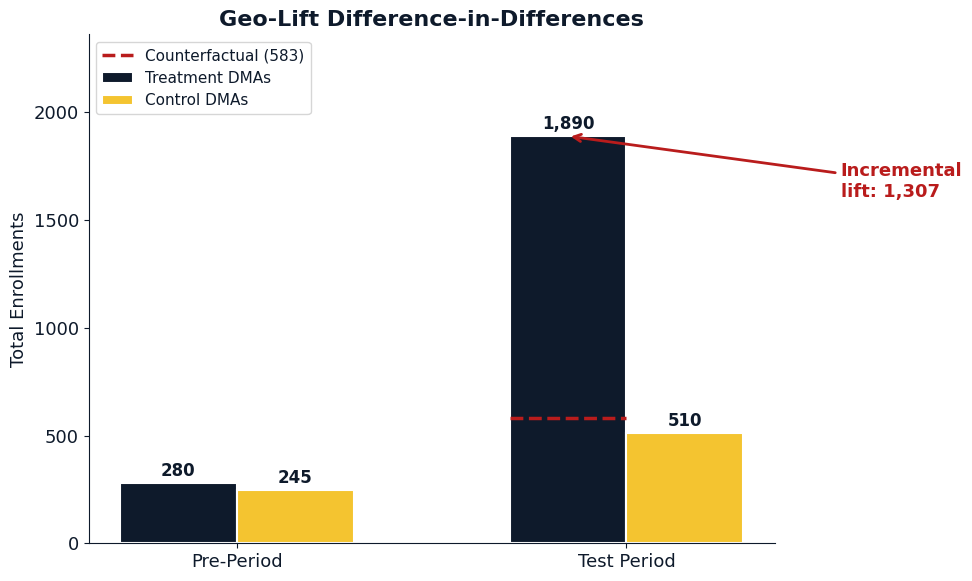

Two independent methods converge within 3% — this is the credibility moment that turns analysis into conviction.


In [25]:
# Chart 4 — Difference-in-Differences Visual
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(2)
width = 0.3

bars_treatment = ax.bar(x - width/2, [treatment_pre, treatment_test], width,
                         label='Treatment DMAs', color=NAVY, edgecolor='white', linewidth=1.5)
bars_control   = ax.bar(x + width/2, [control_pre, control_test], width,
                         label='Control DMAs', color=GOLD, edgecolor='white', linewidth=1.5)

# Counterfactual dashed line on the treatment test bar
ax.hlines(y=counterfactual, xmin=x[1] - width, xmax=x[1],
          colors=RED, linestyles='dashed', linewidth=2.5, label=f'Counterfactual ({counterfactual:,.0f})')

# Annotate bars
for bar in bars_treatment:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontweight='bold', fontsize=12, color=NAVY)
for bar in bars_control:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontweight='bold', fontsize=12, color=NAVY)

# Annotate the incremental lift
ax.annotate(f'Incremental\nlift: {geo_incremental:,.0f}',
            xy=(x[1] - width/2, treatment_test),
            xytext=(x[1] + 0.55, treatment_test * 0.85),
            fontsize=13, fontweight='bold', color=RED,
            arrowprops=dict(arrowstyle='->', color=RED, lw=2))

ax.set_xticks(x)
ax.set_xticklabels(['Pre-Period', 'Test Period'])
ax.set_ylabel('Total Enrollments')
ax.set_title('Geo-Lift Difference-in-Differences')
ax.legend(loc='upper left', frameon=True, fontsize=11)
ax.set_ylim(0, treatment_test * 1.25)
sns.despine()
plt.tight_layout()
plt.savefig('charts/chart_05_diff_in_diff.png')
plt.show()

print(f'Two independent methods converge within {convergence_pct:.0f}% — this is the credibility moment that turns analysis into conviction.')

---
## The Triangulation Table

Four measurement approaches. Four different answers. Only the bottom two are causal and they agree.

In [26]:
# Build triangulation table
triangulation = pd.DataFrame({
    'Measurement Source': [
        'Meta Dashboard (Reported)',
        'Server-Side CRM (Last-Click)',
        'Conversion-Lift Study (Incremental)',
        'Geo-Lift Study (Incremental)'
    ],
    'Conversions': [
        meta_reported,
        meta_server,
        round(incremental_enrollments_lift),
        round(geo_incremental)
    ],
    'CPA': [
        total_spend / meta_reported,
        total_spend / meta_server,
        incremental_cpa_lift,
        geo_cpa
    ]
})

triangulation['Conversions'] = triangulation['Conversions'].apply(lambda x: f'{x:,.0f}')
triangulation['CPA'] = triangulation['CPA'].apply(lambda x: f'${x:,.2f}')

print('='*70)
print('  TRIANGULATION SUMMARY')
print('='*70)
print(triangulation.to_string(index=False))
print('='*70)

  TRIANGULATION SUMMARY
                 Measurement Source Conversions     CPA
          Meta Dashboard (Reported)       4,200  $47.62
       Server-Side CRM (Last-Click)       2,100  $95.24
Conversion-Lift Study (Incremental)       1,266 $157.98
       Geo-Lift Study (Incremental)       1,307 $153.01


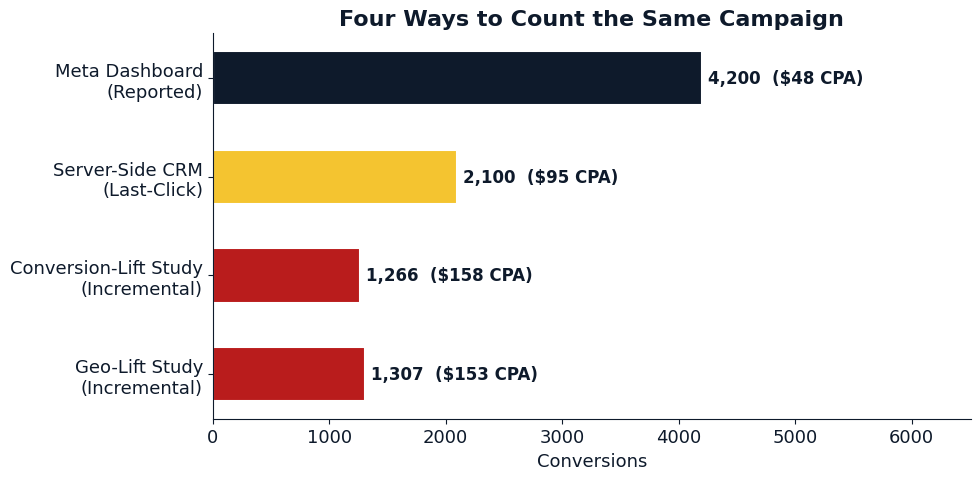

The dashboard claims 4,200 conversions. Two independent causal methods agree: the real number is closer to 1,266.


In [27]:
# Chart 5 — Triangulation Horizontal Bar
fig, ax = plt.subplots(figsize=(10, 5))

sources = [
    'Geo-Lift Study\n(Incremental)',
    'Conversion-Lift Study\n(Incremental)',
    'Server-Side CRM\n(Last-Click)',
    'Meta Dashboard\n(Reported)'
]
conv_values = [
    round(geo_incremental),
    round(incremental_enrollments_lift),
    meta_server,
    meta_reported
]
cpa_values = [
    geo_cpa,
    incremental_cpa_lift,
    total_spend / meta_server,
    total_spend / meta_reported
]
bar_colors = [RED, RED, GOLD, NAVY]

bars = ax.barh(sources, conv_values, color=bar_colors, height=0.55, edgecolor='white', linewidth=1.5)

for bar, val, cpa in zip(bars, conv_values, cpa_values):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,}  (${cpa:,.0f} CPA)', va='center', fontweight='bold', fontsize=12, color=NAVY)

ax.set_xlabel('Conversions')
ax.set_title('Four Ways to Count the Same Campaign')
ax.set_xlim(0, meta_reported * 1.55)
sns.despine()
plt.tight_layout()
plt.savefig('charts/chart_06_triangulation.png')
plt.show()

print(f'The dashboard claims 4,200 conversions. Two independent causal methods agree: the real number is closer to {round(incremental_enrollments_lift):,}.')

---
## The Recommendation

### Meta is driving incremental enrollments, but at 3.3x the CPA the dashboard claims. Q4 budget should not be doubled; it should be re-scoped.

Three things that change Monday morning:

1. **Reset the Meta CPA target from ~$48 to ~$158.** The dashboard number is a vanity metric. Every budget decision, every optimization conversation, every performance review should use the incremental CPA as the baseline.

2. **Cap Meta budget at the level where $158 CPA is LTV-positive.** If the lifetime value of a Savings Card enrollee supports a $158 acquisition cost, maintain spend. If it doesn't, scale back until the unit economics work. The answer depends on conversion-to-prescription rates and average patient tenure ; data the finance team has.

3. **Run the same lift test on Google Search, YouTube, and Programmatic.** These channels have not been incrementality-tested. Google Search may be capturing high-intent users who would have enrolled anyway (brand search cannibalization). Programmatic may be performing worse than its dashboard suggests. We don't know until we test.

### One thing that does NOT change:

**Do not kill Meta.** It is still driving ~1,266 real, incremental Savings Card enrollments that would not have happened without the campaign. That is real value. The issue is not that Meta doesn't work ; it's that the dashboard overstates *how well* it works, which leads to over-investment.

---
## Limitations

Every analysis has boundaries. These are ours:

- **Average treatment effect, not heterogeneous effects.** The lift study measures the overall impact of the Meta campaign across the entire audience. It does not tell us whether the lift is concentrated in certain demographics, geographies, or intent segments. Subgroup analysis would require a larger sample or a different experimental design.

- **Lift may not be stable over time.** The 18.75% relative lift was measured during an 8-week campaign. Creative fatigue, audience saturation, and novelty effects can all erode lift over longer time horizons. Repeating the test in Q4 would confirm durability.

- **Geo-lift assumes parallel pre-period trends.** The difference-in-differences approach is valid only if treatment and control markets would have trended similarly without intervention. We verified this visually over the 4-week pre-period, but 4 weeks is a short baseline. Seasonality or local market shocks could violate the assumption.

- **Savings Card enrollment is a proxy, not the revenue event.** A Savings Card enrollment is not a prescription fill. The actual business outcome — a patient starting and staying on Migraneva — sits further down the funnel. Integrating real-world evidence (RWE) or pharmacy claims data would tighten the causal chain from ad exposure to revenue. Until then, we are measuring intent, not action.